#  Generative Adversarial Networks (GAN)
## Introduction

In this tutorial, you will implement a GAN  using PyTorch on MNIST dataset. You will observe its failures and fix it through informed design choices.

## 1. Setup

First, import the required libraries:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else  "mps" if torch.backends.mps.is_available() else "cpu")
print(device)
torch.manual_seed(42)

cuda


## 2. Dataset and DataLoader

We will use the MNIST dataset for training.

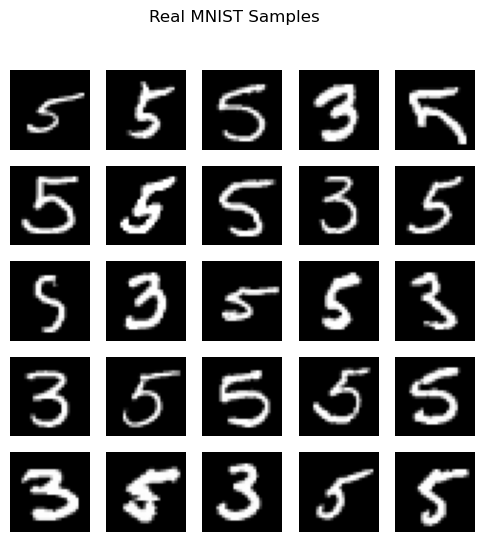

In [2]:


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

indices = (dataset.targets == 5) | (dataset.targets == 3) # if you want to keep images with the label 5
dataset.data, dataset.targets = dataset.data[indices], dataset.targets[indices]

batch_size = 512
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

images, _ = next(iter(loader))

plt.figure(figsize=(6,6))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.axis("off")
plt.suptitle("Real MNIST Samples")
plt.show()


## 3. Define the Generator
The generator takes a random noise vector and generates an image.

📌 Noise input shape: (batch_size, latent_size)

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_size=64, hidden_size=256, image_size=28*28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, image_size),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


## 4. Define the Discriminator
The discriminator classifies images as real or fake.

In [4]:
class Discriminator(nn.Module):

    def __init__(self, hidden_size=256, image_size=28*28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(image_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


## 5. Training loop
The training process involves updating both the generator and discriminator.

In [5]:
def train_gan(epochs, loader, D, G, optimizer_D, optimizer_G, criterion, latent_size=64):
    losses_D = []
    losses_G = []

    for epoch in range(epochs):
        for real, _ in loader:

            batch_size = real.size(0)

            real = real.view(batch_size, -1).to(device)
            
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)
            
            # ---- Train Discriminator ----
            D.zero_grad()

            D_real = D(real)
            errD_real = criterion(D_real, real_labels)

            z = torch.randn(batch_size, latent_size).to(device)
            fake = G(z)
            D_fake = D(fake.detach())
            errD_fake = criterion(D_fake, fake_labels)
       
            loss_D = errD_real + errD_fake
            loss_D.backward()
            optimizer_D.step()

            # ---- Train Generator ----
            G.zero_grad()
            D_fake = D(fake)
            loss_G = criterion(D_fake, real_labels)
            loss_G.backward()
            optimizer_G.step()
        

        losses_D.append(loss_D.item())
        losses_G.append(loss_G.item())
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

    plt.figure(figsize=(10,5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(losses_G,label="G")
    plt.plot(losses_D,label="D")
    plt.xlabel("iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    


## 6. Create and train a GAN

Epoch [1/100] | D Loss: 0.9155 | G Loss: 0.6657
Epoch [2/100] | D Loss: 1.2165 | G Loss: 0.6251
Epoch [3/100] | D Loss: 1.2889 | G Loss: 0.6811
Epoch [4/100] | D Loss: 1.2345 | G Loss: 0.7770
Epoch [5/100] | D Loss: 1.2486 | G Loss: 0.8933
Epoch [6/100] | D Loss: 1.1314 | G Loss: 0.9653
Epoch [7/100] | D Loss: 1.2400 | G Loss: 0.8273
Epoch [8/100] | D Loss: 1.3448 | G Loss: 0.6641
Epoch [9/100] | D Loss: 1.2890 | G Loss: 0.7260
Epoch [10/100] | D Loss: 1.1844 | G Loss: 0.9452
Epoch [11/100] | D Loss: 1.0713 | G Loss: 0.8660
Epoch [12/100] | D Loss: 0.8398 | G Loss: 1.0553
Epoch [13/100] | D Loss: 0.7057 | G Loss: 1.3684
Epoch [14/100] | D Loss: 0.4589 | G Loss: 1.9271
Epoch [15/100] | D Loss: 0.5531 | G Loss: 2.2502
Epoch [16/100] | D Loss: 0.5256 | G Loss: 2.3793
Epoch [17/100] | D Loss: 0.2605 | G Loss: 2.4004
Epoch [18/100] | D Loss: 0.3940 | G Loss: 2.1728
Epoch [19/100] | D Loss: 0.6150 | G Loss: 0.9319
Epoch [20/100] | D Loss: 0.6401 | G Loss: 1.6717
Epoch [21/100] | D Loss: 0.47

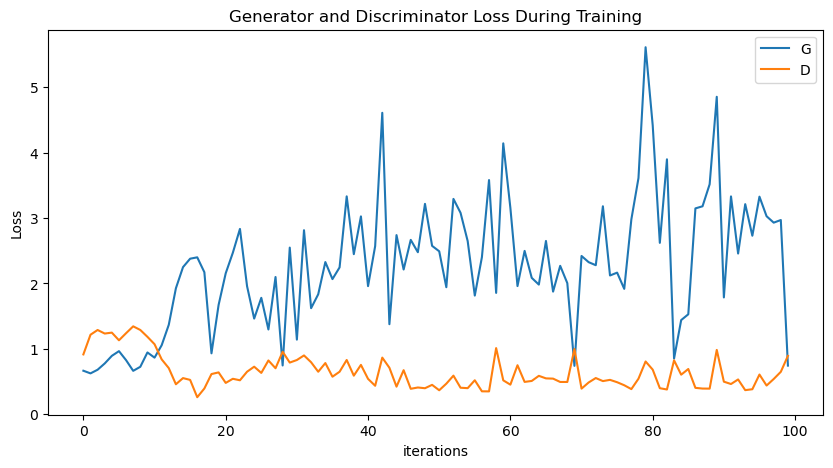

In [6]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 100

train_gan(epochs, loader, D, G, optimizer_D, optimizer_G, criterion)

## 6. Generate and Visualize Fake Images


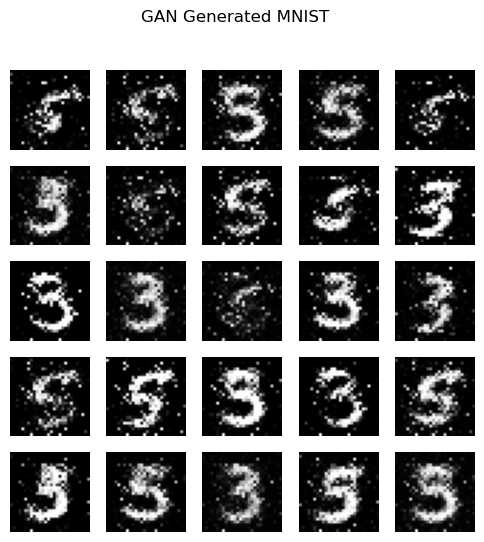

In [7]:
def generate_fakes(G, n = 100, latent_size=64):
    z = torch.randn(n, latent_size).to(device)
    samples = G(z).detach().cpu()
    samples = samples.view(samples.size(0), 1, 28, 28)

    plt.figure(figsize=(6,6))
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.imshow(samples[i][0], cmap="gray")
        plt.axis("off")
    plt.suptitle("GAN Generated MNIST")
    plt.show()

generate_fakes(G)

### Baseline GAN results

The baseline GAN was trained using a latent space of 64 dimensions. The generated samples already resemble the MNIST digits used during training, which in this case are only the digits 3 and 5.

Visually, many samples are recognizable and correspond to the target classes. However, the images still contain noticeable background noise and some digits appear blurry or partially deformed. This indicates that the generator has learned the general structure of the data, although the adversarial training is still unstable and the image quality is not fully clean.

As expected in GANs, the loss values alone are not enough to evaluate the model. The visual inspection of the generated samples shows that the model is able to produce plausible digits, but with limited quality and some artifacts.

# Exercises
## 1. Latent space
Reduce the size of the latent space and check the results.


### Exercise 1: Reducing the latent space

In the baseline GAN, the generator receives a random noise vector with 64 dimensions. In this experiment, the latent space is reduced to 16 dimensions.

A smaller latent space gives the generator less information to create different images. Therefore, the generated samples may become less diverse or less detailed. This experiment allows us to observe how the dimension of the noise vector affects the quality and variability of the generated digits.

Epoch [1/100] | D Loss: 0.8913 | G Loss: 0.7053
Epoch [2/100] | D Loss: 1.2130 | G Loss: 0.6195
Epoch [3/100] | D Loss: 1.2884 | G Loss: 0.7401
Epoch [4/100] | D Loss: 1.2424 | G Loss: 0.8560
Epoch [5/100] | D Loss: 1.1392 | G Loss: 1.0155
Epoch [6/100] | D Loss: 1.2143 | G Loss: 1.0185
Epoch [7/100] | D Loss: 1.2013 | G Loss: 1.1459
Epoch [8/100] | D Loss: 0.8171 | G Loss: 1.3492
Epoch [9/100] | D Loss: 1.0750 | G Loss: 1.0251
Epoch [10/100] | D Loss: 1.0523 | G Loss: 1.2028
Epoch [11/100] | D Loss: 1.0403 | G Loss: 0.8711
Epoch [12/100] | D Loss: 1.0374 | G Loss: 1.1613
Epoch [13/100] | D Loss: 0.7606 | G Loss: 1.2411
Epoch [14/100] | D Loss: 0.8351 | G Loss: 1.2317
Epoch [15/100] | D Loss: 0.8138 | G Loss: 1.3169
Epoch [16/100] | D Loss: 0.5343 | G Loss: 2.0780
Epoch [17/100] | D Loss: 0.8500 | G Loss: 2.1102
Epoch [18/100] | D Loss: 0.4915 | G Loss: 2.7516
Epoch [19/100] | D Loss: 0.4966 | G Loss: 2.3273
Epoch [20/100] | D Loss: 1.0048 | G Loss: 3.0534
Epoch [21/100] | D Loss: 0.92

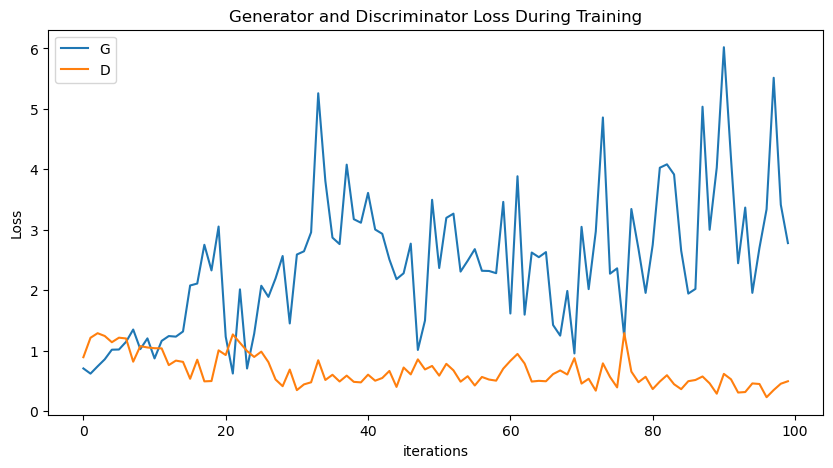

In [8]:
# Exercise 1: Reduce the latent space size

latent_size_small = 16

G_small = Generator(latent_size=latent_size_small).to(device)
D_small = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G_small = optim.Adam(
    G_small.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D_small = optim.Adam(
    D_small.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

epochs = 100

train_gan(
    epochs=epochs,
    loader=loader,
    D=D_small,
    G=G_small,
    optimizer_D=optimizer_D_small,
    optimizer_G=optimizer_G_small,
    criterion=criterion,
    latent_size=latent_size_small
)

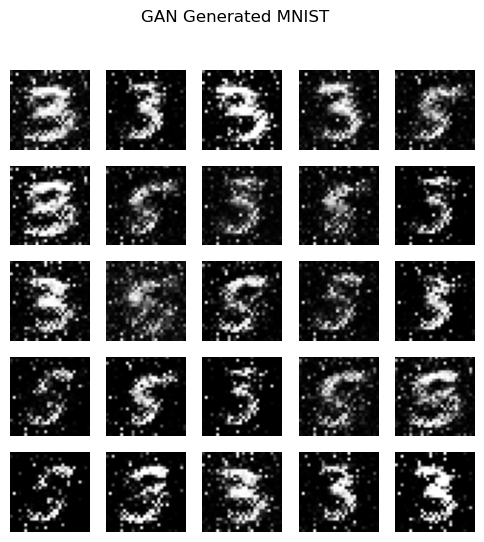

In [9]:
generate_fakes(G_small, latent_size=latent_size_small)

### Effect of reducing the latent space

The GAN was trained again using a smaller latent space of 16 dimensions instead of 64. In this case, the generated samples still resemble the digits 3 and 5, but their visual quality is slightly worse than in the baseline model.

Compared with the previous experiment, the digits appear noisier and more distorted, and the diversity of the generated samples seems lower. This behaviour is consistent with the reduction of the latent space, since the generator receives less random information and has less flexibility to represent different variations of the data distribution.

Therefore, in this experiment, reducing the latent space made the generation process more limited and produced slightly poorer samples.


## 2. Label smoothing
One-sided label smoothing is a training technique, commonly used in GANs, that slightly softens the real labels given to the discriminator, while leaving the fake labels unchanged. In a vanilla GAN, real images are labeled with 1.0 and fake images with 0.0. This encourages the discriminator to become very confident, which can cause vanishing gradients for the generator, training instability or overconfident discriminator decisions.

Smoothing only real labels prevents the discriminator from becoming overconfident, keeps the adversarial game meaningful and preserves strong gradients for the generator.

Modify the training function to replace the 1.0 label value of real images with random values uniformly distributed in a range close to 1. Train a new GAN and check the results.

In [10]:
def train_gan_label_smoothing(
    epochs,
    loader,
    D,
    G,
    optimizer_D,
    optimizer_G,
    criterion,
    latent_size=64,
    real_label_min=0.8,
    real_label_max=1.0
):
    losses_D = []
    losses_G = []

    for epoch in range(epochs):
        for real, _ in loader:

            batch_size = real.size(0)
            real = real.view(batch_size, -1).to(device)

            # Real labels are smoothed using random values close to 1
            real_labels_smooth = torch.empty(batch_size, 1).uniform_(
                real_label_min,
                real_label_max
            ).to(device)

            # Fake labels remain equal to 0
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Labels used to train the generator
            real_labels_for_G = torch.ones(batch_size, 1).to(device)

            # ---- Train Discriminator ----
            D.zero_grad()

            D_real = D(real)
            errD_real = criterion(D_real, real_labels_smooth)

            z = torch.randn(batch_size, latent_size).to(device)
            fake = G(z)

            D_fake = D(fake.detach())
            errD_fake = criterion(D_fake, fake_labels)

            loss_D = errD_real + errD_fake
            loss_D.backward()
            optimizer_D.step()

            # ---- Train Generator ----
            G.zero_grad()

            D_fake = D(fake)
            loss_G = criterion(D_fake, real_labels_for_G)

            loss_G.backward()
            optimizer_G.step()

        losses_D.append(loss_D.item())
        losses_G.append(loss_G.item())

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"D Loss: {loss_D.item():.4f} | "
            f"G Loss: {loss_G.item():.4f}"
        )

    plt.figure(figsize=(10, 5))
    plt.title("Generator and Discriminator Loss During Training with Label Smoothing")
    plt.plot(losses_G, label="G")
    plt.plot(losses_D, label="D")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    return losses_D, losses_G

Epoch [1/100] | D Loss: 1.0475 | G Loss: 0.7434
Epoch [2/100] | D Loss: 1.1559 | G Loss: 0.7782
Epoch [3/100] | D Loss: 1.1296 | G Loss: 0.9171
Epoch [4/100] | D Loss: 1.1482 | G Loss: 0.9735
Epoch [5/100] | D Loss: 1.1953 | G Loss: 0.9447
Epoch [6/100] | D Loss: 1.3391 | G Loss: 0.8075
Epoch [7/100] | D Loss: 1.2296 | G Loss: 0.9393
Epoch [8/100] | D Loss: 1.1463 | G Loss: 1.0586
Epoch [9/100] | D Loss: 0.9840 | G Loss: 1.4128
Epoch [10/100] | D Loss: 0.9418 | G Loss: 1.4814
Epoch [11/100] | D Loss: 0.8003 | G Loss: 1.7608
Epoch [12/100] | D Loss: 0.7542 | G Loss: 1.8531
Epoch [13/100] | D Loss: 0.6650 | G Loss: 2.0587
Epoch [14/100] | D Loss: 0.6990 | G Loss: 2.0533
Epoch [15/100] | D Loss: 0.6783 | G Loss: 2.1383
Epoch [16/100] | D Loss: 0.6008 | G Loss: 2.4120
Epoch [17/100] | D Loss: 0.7077 | G Loss: 2.7992
Epoch [18/100] | D Loss: 0.7817 | G Loss: 0.9705
Epoch [19/100] | D Loss: 1.1490 | G Loss: 2.4568
Epoch [20/100] | D Loss: 0.8311 | G Loss: 1.6770
Epoch [21/100] | D Loss: 1.06

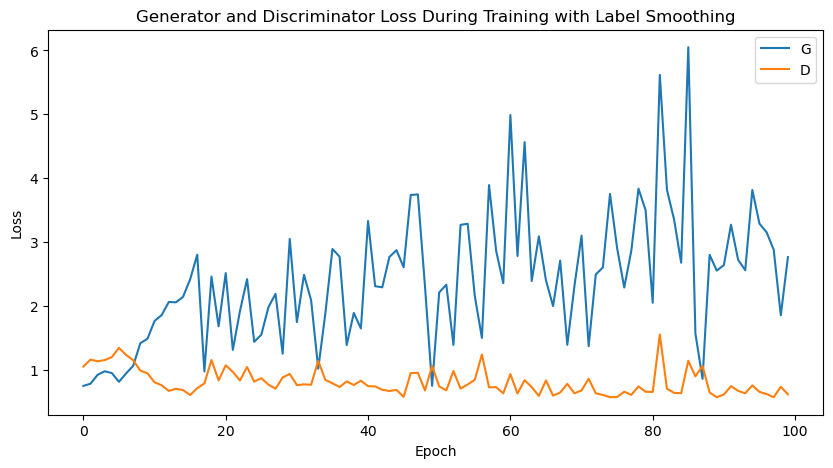

In [11]:
# Exercise 2: Train GAN with one-sided label smoothing

latent_size = 64

G_smooth = Generator(latent_size=latent_size).to(device)
D_smooth = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G_smooth = optim.Adam(
    G_smooth.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D_smooth = optim.Adam(
    D_smooth.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

epochs = 100

losses_D_smooth, losses_G_smooth = train_gan_label_smoothing(
    epochs=epochs,
    loader=loader,
    D=D_smooth,
    G=G_smooth,
    optimizer_D=optimizer_D_smooth,
    optimizer_G=optimizer_G_smooth,
    criterion=criterion,
    latent_size=latent_size,
    real_label_min=0.8,
    real_label_max=1.0
)

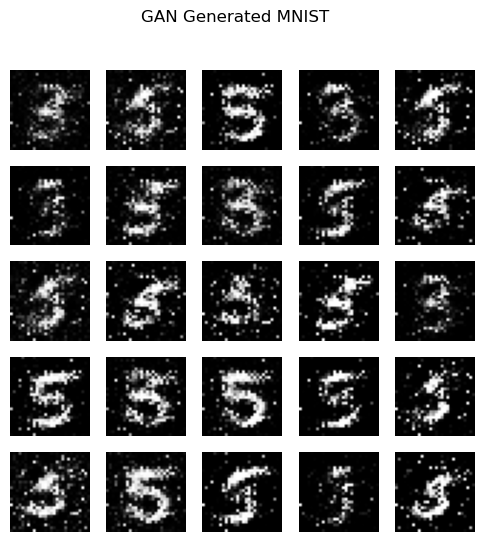

In [12]:
generate_fakes(G_smooth, latent_size=latent_size)

### Effect of one-sided label smoothing

The GAN was also trained using one-sided label smoothing, replacing the real label value 1.0 with random values between 0.8 and 1.0, while keeping fake labels equal to 0.

The generated samples still resemble the digits 3 and 5, which shows that the generator continues learning the target distribution. However, when comparing the generated images with the baseline GAN, the visual improvement is not very clear. The samples still contain noticeable noise and some digits remain blurry or poorly defined.

Therefore, in this experiment, one-sided label smoothing did not produce a strong visual improvement in the generated images. Even so, it remains a useful regularization strategy because it can reduce discriminator overconfidence and help stabilize GAN training.

## Final conclusion

In this notebook, a vanilla GAN was trained on a subset of MNIST containing only the digits 3 and 5. The generator learned to produce digit-like images from random noise, while the discriminator learned to distinguish real images from fake ones.

The baseline GAN was able to generate recognizable samples of both classes, although the images still showed considerable background noise and some distortions. This confirms that the adversarial framework can learn the distribution of the training data, but also highlights the instability of GAN training.

When the latent space was reduced from 64 to 16 dimensions, the quality of the generated samples decreased slightly. The images became noisier and less diverse, which suggests that a smaller latent space limits the expressive capacity of the generator.

One-sided label smoothing was also tested in order to reduce discriminator overconfidence. In this experiment, the generated samples did not show a clear visual improvement over the baseline model, although the technique is still relevant as a stabilization strategy in adversarial training.

Overall, the best visual results were obtained with the baseline GAN. The experiments show that GAN performance is highly sensitive to design choices, and that generated images must always be inspected visually because the loss values alone do not fully reflect sample quality.

## Appendix: Training an improved GAN

After comparing the previous experiments, the baseline GAN with a latent space of 64 dimensions produced the best visual results. Reducing the latent space to 16 dimensions made the generated digits noisier and less diverse, so the improved model keeps the latent size equal to 64.

In this additional experiment, the capacity of both the generator and the discriminator is increased by using a hidden size of 512 instead of 256. One-sided label smoothing is also used to prevent the discriminator from becoming overconfident.

The discriminator learning rate is slightly reduced compared with the generator learning rate. This is done because, in GAN training, if the discriminator learns too quickly, the generator may receive weak gradients and training can become unstable.

The objective of this final experiment is to train a stronger GAN using the best design choices observed in the previous sections.

Epoch [1/150] | D Loss: 1.2178 | G Loss: 0.6890
Epoch [2/150] | D Loss: 1.2935 | G Loss: 0.7685
Epoch [3/150] | D Loss: 1.3027 | G Loss: 0.8431
Epoch [4/150] | D Loss: 1.2606 | G Loss: 0.9031
Epoch [5/150] | D Loss: 1.2522 | G Loss: 0.9134
Epoch [6/150] | D Loss: 1.3282 | G Loss: 0.8514
Epoch [7/150] | D Loss: 1.2538 | G Loss: 0.8820
Epoch [8/150] | D Loss: 1.3595 | G Loss: 0.8133
Epoch [9/150] | D Loss: 1.3061 | G Loss: 0.8839
Epoch [10/150] | D Loss: 1.1944 | G Loss: 1.0025
Epoch [11/150] | D Loss: 1.1985 | G Loss: 1.0016
Epoch [12/150] | D Loss: 1.0740 | G Loss: 1.0996
Epoch [13/150] | D Loss: 1.2827 | G Loss: 0.9572
Epoch [14/150] | D Loss: 1.1870 | G Loss: 0.9863
Epoch [15/150] | D Loss: 1.0918 | G Loss: 1.0907
Epoch [16/150] | D Loss: 1.1473 | G Loss: 1.0397
Epoch [17/150] | D Loss: 1.0792 | G Loss: 1.0953
Epoch [18/150] | D Loss: 0.9864 | G Loss: 1.2368
Epoch [19/150] | D Loss: 1.1178 | G Loss: 1.3972
Epoch [20/150] | D Loss: 0.9272 | G Loss: 1.5514
Epoch [21/150] | D Loss: 0.83

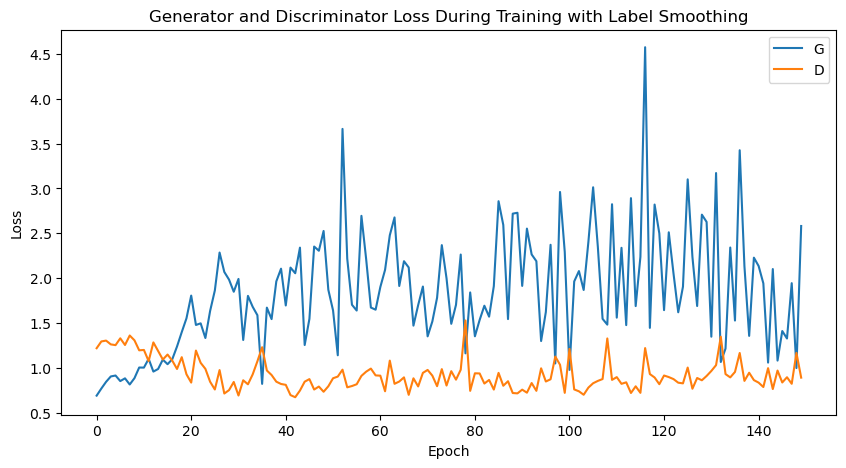

In [13]:
# Appendix: Improved GAN using the best observed design choices

latent_size_best = 64
hidden_size_best = 512
epochs_best = 150

G_best = Generator(
    latent_size=latent_size_best,
    hidden_size=hidden_size_best
).to(device)

D_best = Discriminator(
    hidden_size=hidden_size_best
).to(device)

criterion = nn.BCELoss()

# Slightly lower learning rate for the discriminator
optimizer_G_best = optim.Adam(
    G_best.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D_best = optim.Adam(
    D_best.parameters(),
    lr=0.0001,
    betas=(0.5, 0.999)
)

losses_D_best, losses_G_best = train_gan_label_smoothing(
    epochs=epochs_best,
    loader=loader,
    D=D_best,
    G=G_best,
    optimizer_D=optimizer_D_best,
    optimizer_G=optimizer_G_best,
    criterion=criterion,
    latent_size=latent_size_best,
    real_label_min=0.85,
    real_label_max=1.0
)

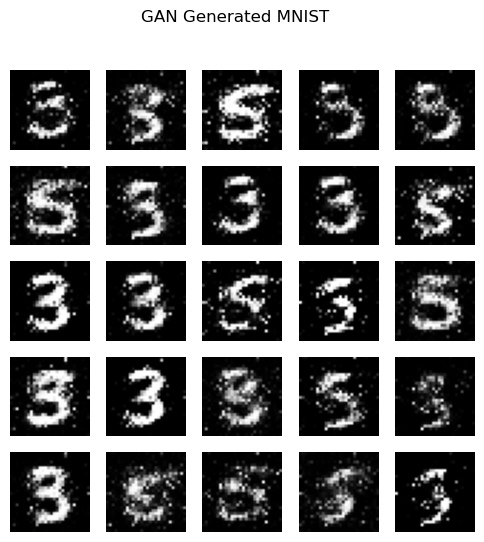

In [14]:
generate_fakes(G_best, latent_size=latent_size_best)

### Appendix conclusion

The improved GAN gave the best visual result in this notebook. Most of the generated images can be recognized as 3s or 5s, and the digits look cleaner than in the experiment with the reduced latent space.

The improvement is probably due to the combination of several changes. The latent space was kept at 64 dimensions, so the generator still had enough input information to produce different samples. The hidden size was increased to 512, which gave the networks more capacity. In addition, label smoothing and a lower learning rate for the discriminator helped to avoid making the discriminator too strong too early.

There are still noisy and ambiguous samples, but this is expected with a simple fully connected GAN. Overall, this final configuration produced the best generated images, so it can be considered the best model tested in this notebook.